In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_excel("/content/uc3m-movilidad-saliente-2023-24-anonimizado (1).xlsx")
df.head()
print(df.shape)
print(df.columns.tolist())

(2001, 45)
['IMPORTANTE', 'cod_universidad', 'des_universidad', 'curso_academico', 'cod_tipo_programa_mov', 'des_tipo_programa_mov', 'cod_programa_movilidad', 'des_programa_movilidad', 'cod_pais_nacionalidad', 'des_pais_nacionalidad', 'lat_pais_nacionalidad', 'lon_pais_nacionalidad', 'cod_continente_nacionalidad', 'des_continente_nacionalidad', 'cod_agregacion_paises_nacionalidad', 'des_agregacion_paises_nacionalidad', 'anio_nacimiento', 'cod_genero', 'des_genero', 'cod_nivel_formativo_origen', 'des_nivel_formativo_origen', 'cod_titulacion_origen', 'des_titulacion_origen', 'cod_universidad_destino', 'des_universidad_destino', 'cod_pais_univ_destino', 'des_pais_univ_destino', 'lat_pais_univ_destino', 'lon_pais_univ_destino', 'cod_continente_univ_destino', 'des_continente_univ_destino', 'cod_agregacion_paises_univ_destino', 'des_agregacion_paises_univ_destino', 'cod_municipio_destino', 'des_municipio_destino', 'cod_comunidad_destino', 'des_comunidad_destino', 'cod_provincia_destino', 'de

# Drop unnecessary columns

In [ ]:
cols_to_drop = [
    "IMPORTANTE",
    "cod_universidad",
    "cod_tipo_programa_mov",
    "cod_programa_movilidad",
    "cod_pais_nacionalidad",
    "lat_pais_nacionalidad",
    "lon_pais_nacionalidad",
    "cod_continente_nacionalidad",
    "cod_agregacion_paises_nacionalidad",
    "des_agregacion_paises_nacionalidad",
    "cod_genero",
    "cod_nivel_formativo_origen",
    "des_nivel_formativo_origen",
    "cod_universidad_destino",
    "cod_pais_univ_destino",
    "lat_pais_univ_destino",
    "lon_pais_univ_destino",
    "cod_continente_univ_destino",
    "cod_agregacion_paises_univ_destino",
    "des_agregacion_paises_univ_destino",
    "cod_municipio_destino",
    "des_municipio_destino",
    "cod_comunidad_destino",
    "des_comunidad_destino",
    "cod_provincia_destino",
    "des_provincia_destino",
    "lat_municipio_destino",
    "lon_municipio_destino",
    "cod_ambito_univ_destino",
    "des_ambito_univ_destino",



]

df = df.drop(columns=cols_to_drop, errors="ignore")
print(df.shape)
df.head()

(2001, 15)


,des_universidad,curso_academico,des_tipo_programa_mov,des_programa_movilidad,des_pais_nacionalidad,des_continente_nacionalidad,anio_nacimiento,des_genero,cod_titulacion_origen,des_titulacion_origen,des_universidad_destino,des_pais_univ_destino,des_continente_univ_destino,mes_inicio_programa,mes_fin_programa
0,Universidad Carlos III de Madrid,2023-24,Estudios y/o proyecto fin de grado,Otras Fuera de la UE,España,Europa,2002,Mujer,7000617.0,Doble Grado en Estudios Internacionales y Cien...,INSTITUT D'ETUDES POLITIQUES DE PARIS (SCIENCE...,Francia,Europa,82023,52024
1,Universidad Carlos III de Madrid,2023-24,Estudios y/o proyecto fin de grado,Otras Fuera de la UE,España,Europa,2003,Mujer,7000617.0,Doble Grado en Estudios Internacionales y Cien...,INSTITUT D'ETUDES POLITIQUES DE GRENOBLE,Francia,Europa,102023,72024
2,Universidad Carlos III de Madrid,2023-24,Estudios y/o proyecto fin de grado,Otras Fuera de la UE,España,Europa,2002,Mujer,7000617.0,Doble Grado en Estudios Internacionales y Cien...,OTRA UNIVERSIDAD FUERA DE LA UE,Nueva Zelandia,Oceanía,92023,62024
3,Universidad Carlos III de Madrid,2023-24,Estudios y/o proyecto fin de grado,ERASMUS +,España,Europa,2003,Mujer,7000617.0,Doble Grado en Estudios Internacionales y Cien...,OTRA UNIVERSIDAD FUERA DE LA UE,Estados Unidos de América,Américas,82023,122023
4,Universidad Carlos III de Madrid,2023-24,Estudios y/o proyecto fin de grado,Otras Fuera de la UE,España,Europa,2001,Mujer,7000617.0,Doble Grado en Estudios Internacionales y Cien...,OTRA UNIVERSIDAD FUERA DE LA UE,Brasil,Américas,92023,52024


# Check null values

In [ ]:
null_summary = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().mean()*100).round(2)
})

print(null_summary)

                             Null_Count  Null_Percentage
des_universidad                       0              0.0
curso_academico                       0              0.0
des_tipo_programa_mov                 0              0.0
des_programa_movilidad                0              0.0
des_pais_nacionalidad                 0              0.0
des_continente_nacionalidad           0              0.0
anio_nacimiento                       0              0.0
des_genero                            0              0.0
cod_titulacion_origen                80              4.0
des_titulacion_origen                80              4.0
des_universidad_destino               0              0.0
des_pais_univ_destino                 0              0.0
des_continente_univ_destino           0              0.0
mes_inicio_programa                   0              0.0
mes_fin_programa                      0              0.0


# Type of Program per student

des_tipo_programa_mov
Estudios y/o proyecto fin de grado    2001
Name: count, dtype: int64


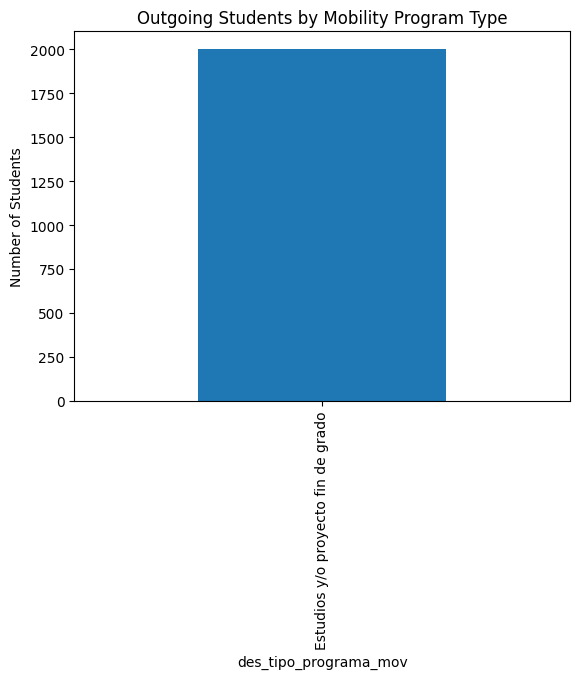

In [ ]:
program_counts = df["des_tipo_programa_mov"].value_counts()

print(program_counts)

plt.figure()
program_counts.plot(kind="bar")
plt.title("Outgoing Students by Mobility Program Type")
plt.ylabel("Number of Students")
plt.show()

# Mobility program per student

des_programa_movilidad
ERASMUS +                1109
Otras Fuera de la UE      795
Otras Dentro de la UE      50
SICUE-SÉNECA               47
Name: count, dtype: int64


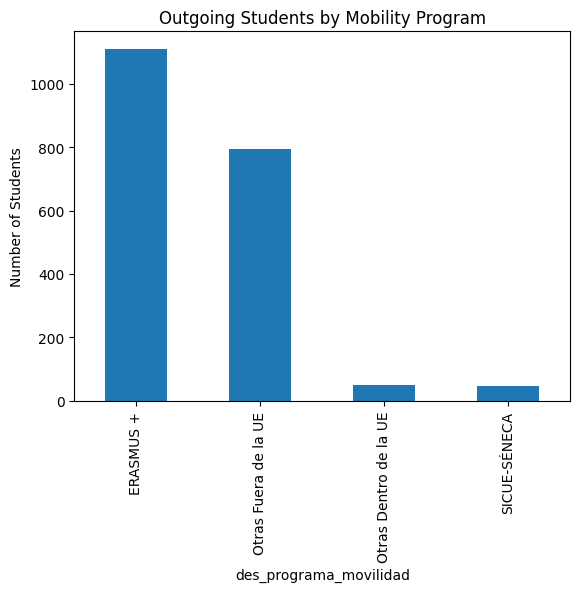

In [ ]:
program_name_counts = df["des_programa_movilidad"].value_counts()

print(program_name_counts)

plt.figure()
program_name_counts.plot(kind="bar")
plt.title("Outgoing Students by Mobility Program")
plt.ylabel("Number of Students")
plt.show()

# Gender distribution

des_genero
Mujer     1156
Hombre     845
Name: count, dtype: int64


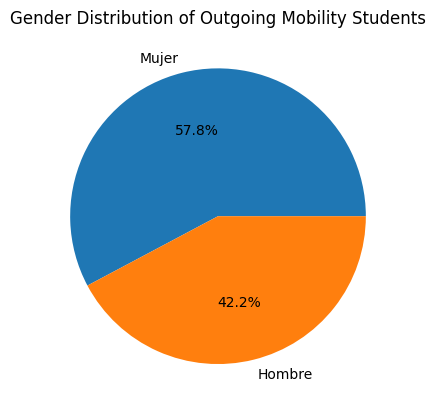

In [ ]:
gender_counts = df["des_genero"].value_counts()

print(gender_counts)

plt.figure()
gender_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution of Outgoing Mobility Students")
plt.ylabel("")
plt.show()

# Save new excel file

In [ ]:
# Save cleaned dataset to new Excel file
output_path = "movsaliente_limpio.xlsx"

df.to_excel(output_path, index=False)

print("File saved as:", output_path)
from google.colab import files
files.download("movsaliente_limpio.xlsx")

File saved as: movsaliente_limpio.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>